<a href="https://colab.research.google.com/github/Sarkis55/Drug-Risk-Analysis/blob/main/Drug_Adverse_Event_Analysis_and_Risk_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Extracting the Data through the FDA's Adverse Event database

In [1]:
import requests
import pandas as pd

# FDA openFDA adverse event API - no key needed for public access
BASE_URL = "https://api.fda.gov/drug/event.json"

# Common drugs to query for a diverse dataset
drugs = [
    "aspirin", "ibuprofen", "metformin", "lisinopril",
    "atorvastatin", "amoxicillin", "omeprazole", "metoprolol"
]

records = []

for drug in drugs:
    params = {
        "search": f'patient.drug.medicinalproduct:"{drug}"',
        "limit": 100
    }
    response = requests.get(BASE_URL, params=params, timeout=15)
    if response.status_code != 200:
        print(f"  Warning: {drug} returned status {response.status_code}")
        continue

    results = response.json().get("results", [])

    for event in results:
        patient = event.get("patient", {})

        # Drug name (first listed drug)
        drugs_list = patient.get("drug", [{}])
        drug_name = drugs_list[0].get("medicinalproduct", drug).strip().upper() if drugs_list else drug.upper()

        # Patient age
        age = patient.get("patientonsetage", None)

        # Patient sex: 1=Male, 2=Female
        sex_raw = patient.get("patientsex", None)

        # Reactions (first listed)
        reactions = patient.get("reaction", [{}])
        reaction = reactions[0].get("reactionmeddrapt", "Unknown") if reactions else "Unknown"

        # Serious (1=serious, 2=not serious)
        serious_raw = event.get("serious", None)

        # Outcome (first reaction outcome)
        outcome = reactions[0].get("reactionoutcome", None) if reactions else None

        records.append({
            "drug_query": drug,
            "drug_name": drug_name,
            "patient_age": age,
            "patient_sex_raw": sex_raw,
            "reaction": reaction,
            "serious_raw": serious_raw,
            "outcome_code": outcome
        })

    print(f"  {drug}: {len(results)} records fetched")

raw_df = pd.DataFrame(records)

print(f"\n{'='*45}")
print(f"Total records fetched : {len(raw_df):,}")
print(f"Columns               : {list(raw_df.columns)}")
print(f"\nSample rows:")
print(raw_df.head(5).to_string())

  aspirin: 100 records fetched
  ibuprofen: 100 records fetched
  metformin: 100 records fetched
  lisinopril: 100 records fetched
  atorvastatin: 100 records fetched
  amoxicillin: 100 records fetched
  omeprazole: 100 records fetched
  metoprolol: 100 records fetched

Total records fetched : 800
Columns               : ['drug_query', 'drug_name', 'patient_age', 'patient_sex_raw', 'reaction', 'serious_raw', 'outcome_code']

Sample rows:
  drug_query                                                  drug_name patient_age patient_sex_raw                  reaction serious_raw outcome_code
0    aspirin                                        DOXYCYCLINE HYCLATE        None               2     Drug hypersensitivity           2            6
1    aspirin                                                     LYRICA          66               2                 Back pain           2            1
2    aspirin  MORPHINE SULFATE EXTENDED-RELEASE TABLETS (RHODES 74-862)        None               2  Cere

## Preprocessing the Data

In [2]:
import pandas as pd
import numpy as np

# Work from raw_df upstream
df = raw_df.copy()
original_count = len(df)

# --- 1. Convert types ---
df["patient_age"] = pd.to_numeric(df["patient_age"], errors="coerce")
df["serious_raw"] = pd.to_numeric(df["serious_raw"], errors="coerce")
df["patient_sex_raw"] = pd.to_numeric(df["patient_sex_raw"], errors="coerce")
df["outcome_code"] = pd.to_numeric(df["outcome_code"], errors="coerce")

# --- 2. Encode patient sex ---
df["sex"] = df["patient_sex_raw"].map({1: "Male", 2: "Female"}).fillna("Unknown")

# --- 3. Encode seriousness (1=Serious, 2=Not Serious in FDA schema) ---
df["serious"] = df["serious_raw"].map({1: "Serious", 2: "Not Serious"}).fillna("Unknown")
df["is_serious"] = (df["serious_raw"] == 1).astype(int)

# --- 4. Encode outcome ---
outcome_map = {
    1: "Recovered", 2: "Recovering", 3: "Not Recovered",
    4: "Recovered with Sequelae", 5: "Fatal", 6: "Unknown"
}
df["outcome"] = df["outcome_code"].map(outcome_map).fillna("Unknown")

# --- 5. Clean drug names: use the query drug name for grouping (normalized) ---
df["drug"] = df["drug_query"].str.title()

# --- 6. Clean reaction text ---
df["reaction"] = df["reaction"].str.strip().str.title()

# --- 7. Filter out invalid ages (keep 0–120) ---
invalid_age_mask = (df["patient_age"] < 0) | (df["patient_age"] > 120)
n_invalid_age = invalid_age_mask.sum()
df.loc[invalid_age_mask, "patient_age"] = np.nan

# --- 8. Keep only needed columns ---
cleaned_df = df[[
    "drug", "drug_name", "patient_age", "sex",
    "reaction", "serious", "is_serious", "outcome"
]].copy()

# --- Summary ---
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)
print(f"Original records     : {original_count:,}")
print(f"Final records        : {len(cleaned_df):,}")
print(f"Invalid ages removed : {n_invalid_age}")
print(f"\nMissing values per column:")
print(cleaned_df.isnull().sum().to_string())
print(f"\nSex distribution:")
print(cleaned_df["sex"].value_counts().to_string())
print(f"\nSeriousness distribution:")
print(cleaned_df["serious"].value_counts().to_string())
print(f"\nOutcome distribution:")
print(cleaned_df["outcome"].value_counts().to_string())
print(f"\nAge stats (non-null):")
print(cleaned_df["patient_age"].describe().round(1).to_string())
print(f"\nSample cleaned rows:")
print(cleaned_df.head(5).to_string())

DATA CLEANING SUMMARY
Original records     : 800
Final records        : 800
Invalid ages removed : 0

Missing values per column:
drug             0
drug_name        0
patient_age    154
sex              0
reaction         0
serious          0
is_serious       0
outcome          0

Sex distribution:
sex
Female     441
Male       332
Unknown     27

Seriousness distribution:
serious
Serious        544
Not Serious    256

Outcome distribution:
outcome
Unknown                    399
Recovered                  162
Not Recovered              132
Recovering                  52
Fatal                       42
Recovered with Sequelae     13

Age stats (non-null):
count    646.0
mean      61.3
std       17.7
min        1.0
25%       53.0
50%       64.0
75%       73.0
max       91.0

Sample cleaned rows:
      drug                                                  drug_name  patient_age     sex                  reaction      serious  is_serious    outcome
0  Aspirin                                 

## Exploratory Data Analysis

In [3]:
import pandas as pd

# ── 1. Events per drug ──────────────────────────────────────────────────────
events_by_drug = (
    cleaned_df.groupby("drug")
    .agg(total_events=("drug", "count"), serious_events=("is_serious", "sum"))
    .assign(seriousness_rate=lambda x: (x["serious_events"] / x["total_events"] * 100).round(1))
    .sort_values("total_events", ascending=False)
)

# ── 2. Top 15 reactions ─────────────────────────────────────────────────────
top_reactions = (
    cleaned_df["reaction"]
    .value_counts()
    .head(15)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "reaction"})
)

# ── 3. Sex breakdown ────────────────────────────────────────────────────────
sex_breakdown = (
    cleaned_df[cleaned_df["sex"] != "Unknown"]
    .groupby(["sex", "serious"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .assign(serious_pct=lambda x: (x.get("Serious", 0) / x["total"] * 100).round(1))
)

# ── 4. Age stats by seriousness ─────────────────────────────────────────────
age_by_seriousness = (
    cleaned_df.dropna(subset=["patient_age"])
    .groupby("serious")["patient_age"]
    .describe()
    .round(1)
)

# ── 5. Outcome summary ──────────────────────────────────────────────────────
outcome_summary = (
    cleaned_df.groupby("outcome")
    .agg(count=("outcome", "count"), serious_pct=("is_serious", "mean"))
    .assign(serious_pct=lambda x: (x["serious_pct"] * 100).round(1))
    .sort_values("count", ascending=False)
)

# ── Print all summaries ─────────────────────────────────────────────────────
print("=" * 55)
print("EDA SUMMARY — FDA Adverse Event Reporting System")
print("=" * 55)

print("\n📋 Events & Seriousness Rate by Drug:")
print(events_by_drug.to_string())

print("\n\n⚠️  Top 15 Reported Adverse Reactions:")
print(top_reactions.to_string(index=False))

print("\n\n👥 Sex Breakdown (Serious vs Not Serious):")
print(sex_breakdown.to_string())

print("\n\n📊 Patient Age Statistics by Seriousness:")
print(age_by_seriousness.to_string())

print("\n\n🩺 Outcome Distribution:")
print(outcome_summary.to_string())

EDA SUMMARY — FDA Adverse Event Reporting System

📋 Events & Seriousness Rate by Drug:
              total_events  serious_events  seriousness_rate
drug                                                        
Amoxicillin            100              91              91.0
Aspirin                100              66              66.0
Atorvastatin           100              88              88.0
Ibuprofen              100              73              73.0
Lisinopril             100              56              56.0
Metformin              100              68              68.0
Metoprolol             100              46              46.0
Omeprazole             100              56              56.0


⚠️  Top 15 Reported Adverse Reactions:
                    reaction  count
    Type 2 Diabetes Mellitus     39
Gastrointestinal Haemorrhage     19
                   Diarrhoea     18
                    Dyspnoea     17
                     Anaemia     12
       Haemoglobin Decreased     12
          

## Comparing Reports of Serious and Non Serious Adverse Effects

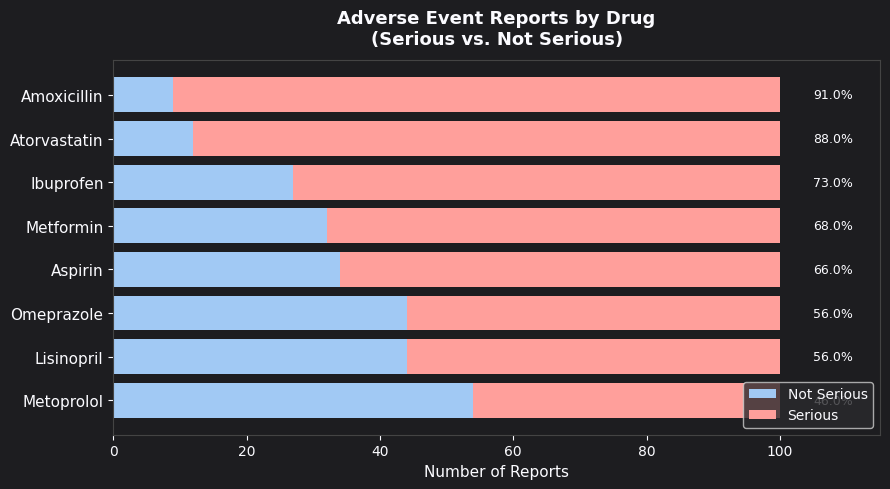

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG = "#1D1D20"
TEXT = "#fbfbff"
SERIOUS_COLOR = "#FF9F9B"
NOT_SERIOUS_COLOR = "#A1C9F4"

drugs_order = events_by_drug.sort_values("seriousness_rate", ascending=True).index.tolist()
serious_vals = [events_by_drug.loc[d, "serious_events"] for d in drugs_order]
not_serious_vals = [events_by_drug.loc[d, "total_events"] - events_by_drug.loc[d, "serious_events"] for d in drugs_order]

seriousness_chart, ax = plt.subplots(figsize=(9, 5))
seriousness_chart.patch.set_facecolor(BG)
ax.set_facecolor(BG)

y = np.arange(len(drugs_order))
ax.barh(y, not_serious_vals, color=NOT_SERIOUS_COLOR, label="Not Serious")
ax.barh(y, serious_vals, left=not_serious_vals, color=SERIOUS_COLOR, label="Serious")

# Rate labels on the right
for i, (drug, rate) in enumerate(zip(drugs_order, [events_by_drug.loc[d, "seriousness_rate"] for d in drugs_order])):
    ax.text(105, i, f"{rate}%", va="center", ha="left", color=TEXT, fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(drugs_order, color=TEXT, fontsize=11)
ax.set_xlabel("Number of Reports", color=TEXT, fontsize=11)
ax.set_title("Adverse Event Reports by Drug\n(Serious vs. Not Serious)", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax.tick_params(colors=TEXT)
ax.set_xlim(0, 115)
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

legend = ax.legend(frameon=True, facecolor="#2a2a2d", labelcolor=TEXT, fontsize=10, loc="lower right")
seriousness_chart.tight_layout()